## **Simulation Analysis**

This notebook contains a selection of plots and other analyses of the simulations conducted in run_simulation.py. Please ensure that the simulations are complete before executing this notebook.

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from plot_osc import *
import os
import pandas as pd
from bat_class import BatOsc, Ball, bat_from_pkl, ball_from_pkl, ball_from_json

In [32]:
#setup paths
results_standard_path = 'results/AdleyOld'
results_torpedo_path = 'results/AdleyNewMod2'
fname = 'bat_impact_{}.pkl'
torp_fname = results_torpedo_path + '/' + fname
standard_fname = results_standard_path + '/' + fname

## All exit velos

In [35]:
results_df = pd.read_csv("results/impact_location_vs_exit_velocitySIM2.csv")
# torp_df = pd.read_csv(results_torpedo_path + '/all_results.csv')
# standard_df = pd.read_csv(results_standard_path + '/all_results.csv')

#alan data
alan_results = pd.read_csv('data/bats/AdleyBats.csv')
alan_results.rename(columns={'vf/vi-1': 'torp_vf', 'vf/vi-2': 'standard_vf'}, inplace=True)

In [40]:
ball = ball_from_json('data/balls/ballAdley.json')
vi= ball.initial_velocity

In [41]:
#inches from tip
L = max(results_df['idx'])
results_df['inches_tip'] = (L - results_df['idx']) / 2.54 #convert to inches
results_df['vf/vi_T'] = results_df['torpedo_vf'] / vi
results_df['vf/vi_S'] = results_df['standard_vf'] / vi

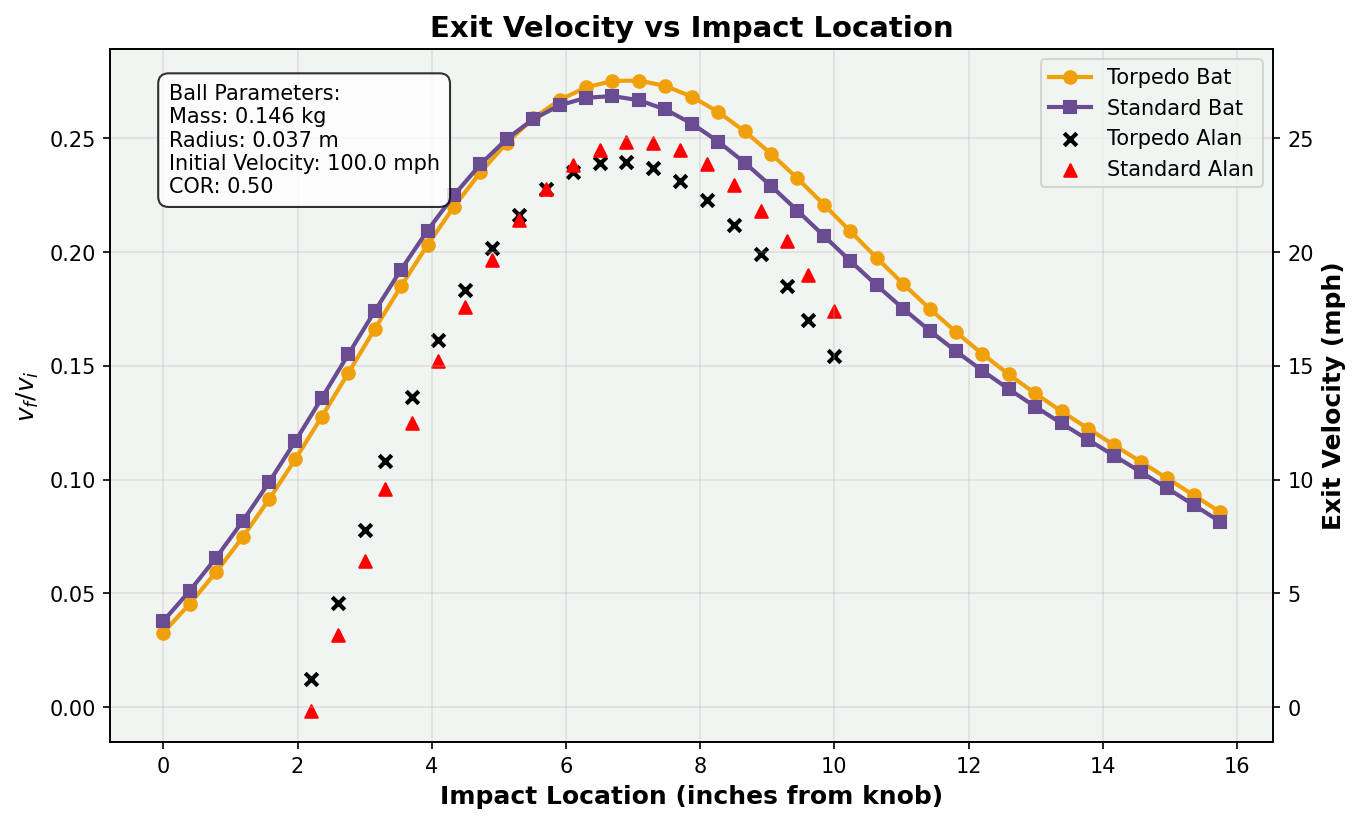

In [42]:
def mps_to_mph(v):
    """Convert velocity from meters per second to miles per hour."""
    return v * 2.23694
def metres_to_inches(metres):
    """Convert length from meters to inches."""
    return metres / 0.0254

fig, ax = plt.subplots(figsize=(10, 6))
plt.title(r'Exit Velocity vs Impact Location')


plt.plot(results_df['inches_tip'], results_df['torpedo_vf'] / vi, label='Torpedo Bat', marker='o', color = colors[0])
plt.plot(results_df['inches_tip'], results_df['standard_vf'] / vi, label='Standard Bat', marker='s', color = colors[3])
plt.scatter(alan_results['ztip'], alan_results['torp_vf'], label='Torpedo Alan', marker='x', color = 'black')
plt.scatter(alan_results['ztip'], alan_results['standard_vf'], label='Standard Alan', marker='^', color = 'red')

ax.set_xlabel('Impact Location (inches from knob)')
ax.set_ylabel(r'$v_f / v_i$', color='black')
# ax.set_ylim(min(np.min(torp_df['vf'] / 100), np.min(standard_df['vf'] / 100)) * 0.9, max(np.max(torp_df['vf'] / 100), np.max(standard_df['vf'] / 100)) * 1.1)


# ax.axvspan(0.66, 0.69, color='yellow', alpha=0.3, label='Sweet Spot Region')
plt.legend()
#add box on top left with ball params
ball_params_text = f"Ball Parameters:\nMass: {ball.mass:.3f} kg\nRadius: {ball.radius:.3f} m\nInitial Velocity: {mps_to_mph(ball.initial_velocity):.1f} mph\nCOR: {ball.e0:.2f}"
plt.text(0.05, 0.95, ball_params_text, transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

# Add secondary y-axis on right with mph scale
ax2 = ax.twinx()
ax2.set_ylabel('Exit Velocity (mph)', color='black')
ymin_mps, ymax_mps = ax.get_ylim()
ax2.set_ylim(mps_to_mph(ymin_mps * vi), mps_to_mph(ymax_mps * vi))
ax2.grid(False)

plt.savefig("midterm_report/plots/impact_location_vs_exit_velocitySIM2.pdf")
plt.show()

In [ ]:
diff = -max(summary_df['standard_vf']) + max(summary_df['torpedo_vf'])
diff = mps_to_mph(diff)
print(f"Difference in max exit velocity between torpedo and standard bat: {diff:.2f} mph")

Difference in max exit velocity between torpedo and standard bat: 0.68 mph


## **Max Force vs Impact Location**

In [ ]:
torp_dynamics = pd.read_csv('results/AdleyNewMod2/all_results.csv')
standard_dynamics = pd.read_csv('results/AdleyOld/all_results.csv')

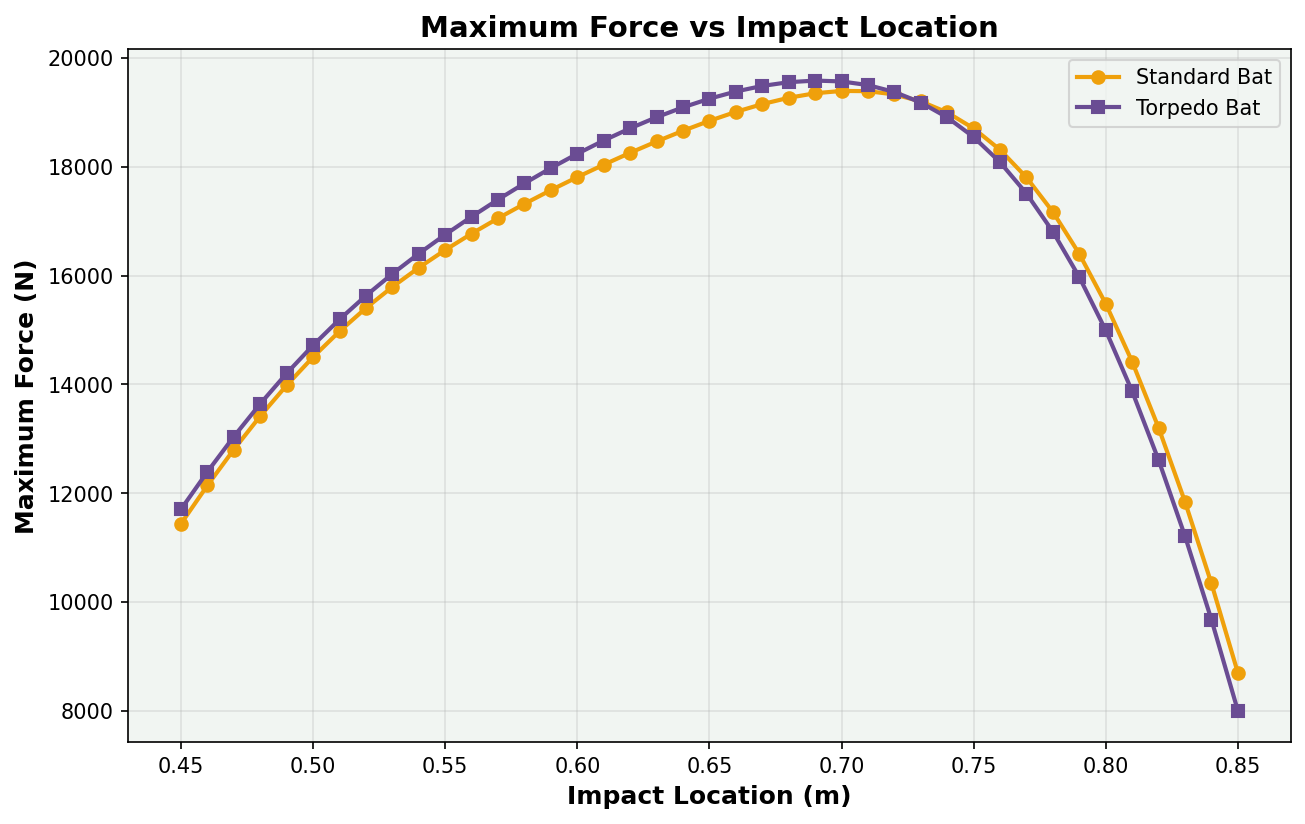

In [ ]:
plt.plot(standard_dynamics['idx'] *1e-2, standard_dynamics['max_F'], label='Standard Bat', marker='o', color = colors[0])
plt.plot(torp_dynamics['idx'] *1e-2, torp_dynamics['max_F'], label='Torpedo Bat', marker='s', color = colors[3])
plt.xlabel('Impact Location (m)')
plt.ylabel('Maximum Force (N)')
plt.title('Maximum Force vs Impact Location')
plt.legend()
plt.savefig('midterm_report/plots/max_force_vs_impact_location.pdf')
plt.show()

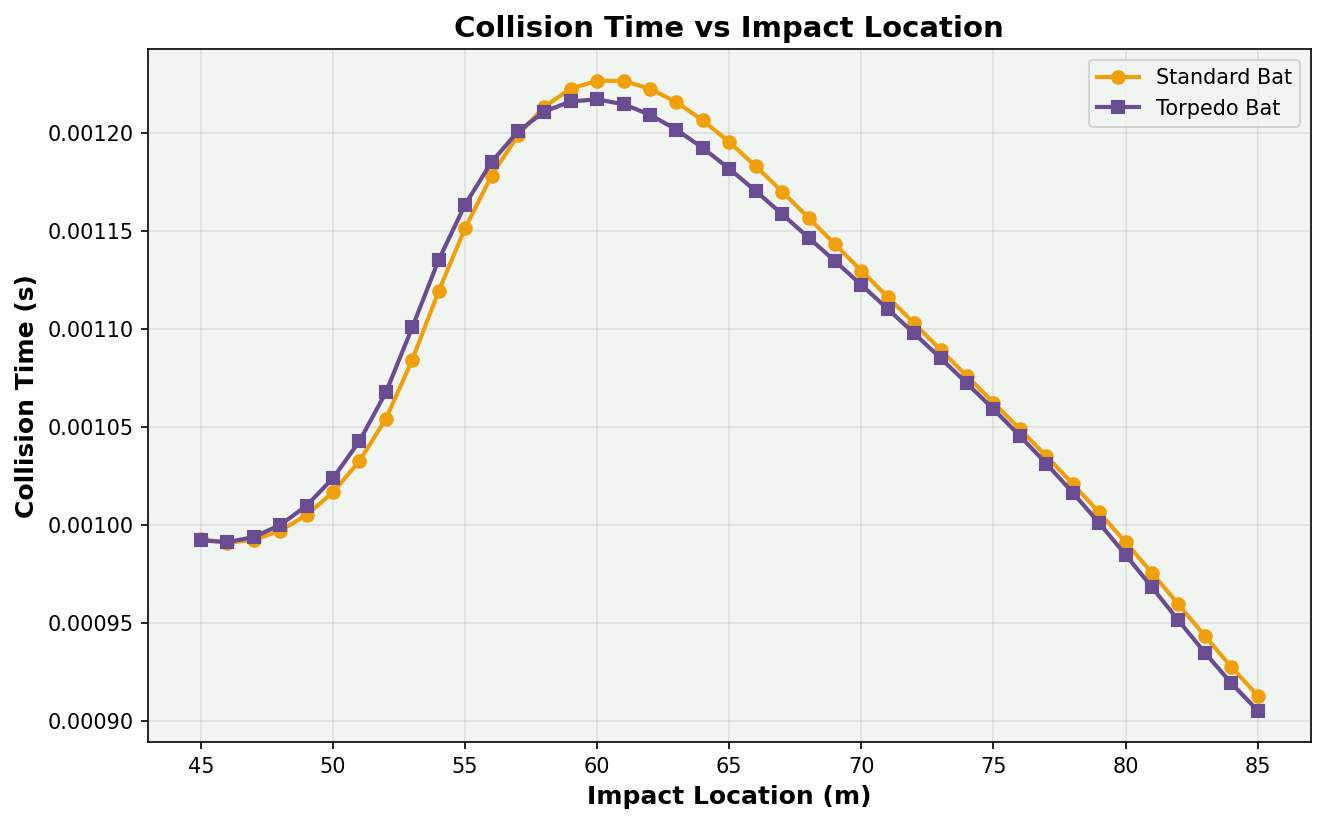

In [ ]:
plt.plot(standard_dynamics['idx'], standard_dynamics['coll_t'], label='Standard Bat', marker='o', color = colors[0])
plt.plot(torp_dynamics['idx'], torp_dynamics['coll_t'], label='Torpedo Bat', marker='s', color = colors[3])
plt.xlabel('Impact Location (m)')
plt.ylabel('Collision Time (s)')
plt.title('Collision Time vs Impact Location')
plt.legend()
plt.savefig('midterm_report/plots/collision_time_vs_impact_location.pdf')
plt.show()

In [4]:
plt.plot(standard_dynamics['idx'], standard_dynamics['max_u'], label='Standard Bat', marker='o', color = colors[0])
plt.plot(torp_dynamics['idx'], torp_dynamics['max_u'], label='Torpedo Bat', marker='s', color = colors[3])
plt.xlabel('Impact Location (m)')
plt.ylabel('Maximum Compression (m)')
plt.title('Maximum Compression vs Impact Location')
plt.legend()
plt.savefig('midterm_report/plots/max_compression_vs_impact_location.pdf')
plt.show()

NameError: name 'standard_dynamics' is not defined